# Network Analysis EDA

## Setup

In [ ]:
# Import Packages
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import community
from networkx.algorithms import bipartite as nxb
from collections import Counter
from itertools import combinations

In [ ]:
def build_tokens(df: pd.DataFrame, body_col: str = "article_body") -> pd.DataFrame:
    if body_col not in df.columns:
        raise KeyError(f"Column '{body_col}' not found in DataFrame.")
    out = df.copy()
    out["tokens"] = out[body_col].fillna("").apply(preprocess_article_text_nltk)
    out["keyword_counts"] = out["tokens"].apply(lambda toks: Counter(toks))
    return out

df_conv = build_tokens(df_conv, body_col="article_body")

In [ ]:
### keyword frequency table 
def keyword_frequency_table(df: pd.DataFrame, tokens_col: str = "tokens") -> pd.DataFrame:
    if tokens_col not in df.columns:
        raise KeyError(f"Column '{tokens_col}' not found in DataFrame.")
    kw = (df.explode(tokens_col)
            .groupby(tokens_col)
            .size()
            .reset_index(name="frequency")
            .sort_values("frequency", ascending=False)
            .rename(columns={tokens_col: "keyword"}))
    return kw

keywords_df = keyword_frequency_table(df_conv)
display(keywords_df.head(25))

In [ ]:
### keyword co-occurence list
def keyword_cooccurrence_edges(df: pd.DataFrame, tokens_col: str = "tokens", min_co: int = 2) -> pd.DataFrame:
    """
    Builds edges between keywords that co-occur in the same article.
    Each article contributes at most one count per keyword pair (set() ensures uniqueness per article).
    """
    rows = []
    for toks in df[tokens_col].dropna():
        uniq = sorted(set(toks))
        rows.extend((a, b) for a, b in combinations(uniq, 2))
    if not rows:
        return pd.DataFrame(columns=["kw1", "kw2", "weight"])
    edges = (pd.DataFrame(rows, columns=["kw1", "kw2"])
               .value_counts()
               .reset_index(name="weight")
               .sort_values("weight", ascending=False))
    # prune weak edges
    edges = edges[edges["weight"] >= min_co].reset_index(drop=True)
    return edges

edges_kw = keyword_cooccurrence_edges(df_conv, tokens_col="tokens", min_co=2)
display(edges_kw.head(25))
print("keywords:", keywords_df.shape[0], "| co-occurrence edges:", edges_kw.shape[0])

In [ ]:
### building keyword graphs 
def build_keyword_graph(edges_kw: pd.DataFrame, min_weight: int = 2) -> nx.Graph:
    """
    edges_kw columns: ['kw1','kw2','weight']
    Creates an undirected weighted graph of keyword co-occurrence.
    """
    required = {"kw1","kw2","weight"}
    if not required.issubset(edges_kw.columns):
        raise ValueError(f"edges_kw must have columns {required}")
    df = edges_kw.copy()
    df = df[df["weight"] >= min_weight]
    G = nx.Graph()
    G.add_weighted_edges_from(df[["kw1","kw2","weight"]].itertuples(index=False, name=None))
    return G

In [ ]:
### visualizing the graphs 
def visualize_keyword_graph(
    G: nx.Graph,
    title: str = "Keyword Co-occurrence Network",
    label_top: int = 30,
    edge_keep_pct: int = 70,      # keep strongest X% edges by weight
    top_nodes_by: str = "strength" # "strength" (weighted degree) | "degree"
):
    if G.number_of_nodes() == 0:
        print("Graph is empty."); return

    # keep strongest edges by percentile
    w = np.array([G[u][v].get("weight", 1) for u, v in G.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return

    # largest connected component
    comps = list(nx.connected_components(H))
    H = H.subgraph(max(comps, key=len)).copy()

    # node sizes by weighted degree (“strength”)
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    degree = dict(H.degree())
    size_map = {n: 120 + 14*np.log1p(strength.get(n, 1)) for n in H.nodes()}
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]

    # layout
    pos = nx.spring_layout(H, seed=42, k=1/np.sqrt(max(1, H.number_of_nodes())))

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    nx.draw_networkx_nodes(H, pos, node_size=[size_map[n] for n in H.nodes()])

    # labels: top nodes by chosen metric
    if top_nodes_by == "degree":
        rank = sorted(degree.items(), key=lambda x: x[1], reverse=True)
    else:
        rank = sorted(strength.items(), key=lambda x: x[1], reverse=True)
    top_nodes = {n for n, _ in rank[:label_top]}
    nx.draw_networkx_labels(H, pos, labels={n: n for n in top_nodes}, font_size=9)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
### Top Edges, Top Keywords by strength
def keyword_lists(G: nx.Graph, edges_kw: pd.DataFrame, top_n: int = 25):
    # strongest edges (by weight)
    edge_table = (edges_kw.sort_values("weight", ascending=False)
                           .head(top_n)
                           .reset_index(drop=True))

    # node strength (weighted degree)
    strength = pd.Series({n: sum(G[n][nbr].get("weight",1) for nbr in G.neighbors(n)) for n in G.nodes()}, name="strength")
    top_strength = strength.sort_values(ascending=False).head(top_n).to_frame()

    # classic centralities (unweighted degree & betweenness on giant component)
    if G.number_of_nodes() > 0 and G.number_of_edges() > 0:
        comps = list(nx.connected_components(G))
        H = G.subgraph(max(comps, key=len)).copy()
        deg = pd.Series(dict(H.degree()), name="degree").sort_values(ascending=False).head(top_n).to_frame()
        btw = pd.Series(nx.betweenness_centrality(H, normalized=True), name="betweenness") \
                .sort_values(ascending=False).head(top_n).to_frame()
    else:
        deg = pd.DataFrame(columns=["degree"])
        btw = pd.DataFrame(columns=["betweenness"])

    return edge_table, top_strength, deg, btw

In [ ]:
### color-coding communities
def keyword_communities(G: nx.Graph, min_size: int = 5):
    if G.number_of_nodes() == 0:
        return {}
    # greedy modularity communities (no extra deps)
    comms = list(community.greedy_modularity_communities(G))
    # keep only communities with at least min_size
    return {i: sorted(list(c)) for i, c in enumerate(c for c in comms if len(c) >= min_size)}

In [ ]:
G_kw = build_keyword_graph(edges_kw, min_weight=2)
print("keywords:", G_kw.number_of_nodes(), "| edges:", G_kw.number_of_edges())

# 2) Visualize (tune these like you did for Source→Topic)
visualize_keyword_graph(
    G_kw,
    title="Keyword Co-occurrence (min_weight=2, top edges kept)",
    label_top=30,
    edge_keep_pct=75,         # keep strongest 75% edges → prune 25% weakest
    top_nodes_by="strength"   # or "degree"
)

# 3) Lists (tables) like before
edge_table, top_strength, deg_table, btw_table = keyword_lists(G_kw, edges_kw, top_n=25)
display(edge_table.head(25))      # strongest keyword pairs
display(top_strength.head(25))    # most influential keywords by weighted degree
display(deg_table.head(25))       # highest-degree keywords
display(btw_table.head(25))       # highest-betweenness keywords

# 4) (Optional) Communities
comms = keyword_communities(G_kw, min_size=5)
for cid, members in comms.items():
    print(f"Community {cid} (n={len(members)}):", ", ".join(members[:15]), "...")

In [ ]:
df = pd.read_parquet("../data_storage/processed_data/sampled_data.parquet")

## Analysis

In [ ]:
DF = df
SOURCE_COL = "source_name"
TOPIC_COL  = "tag_name"

WEIGHT_BY = ["circulation_size", "vipr_weight", "hit_strength"]
WEIGHT_WEIGHTS = None   

MIN_EDGE_WEIGHT = 0.2
MIN_TOPICS_PER_SOURCE = 2
MIN_SOURCES_PER_TOPIC = 2
USE_TFIDF = True

EDGE_KEEP_PCT_BIP = 75
EDGE_KEEP_PCT_PROJ = 70
LABEL_SOURCES_TOP = 25
LABEL_TOPICS_TOP = 8

# 1) Rank-only combiner
def _combine_rankpct(df: pd.DataFrame, cols: list[str], weights: list[float] | None = None) -> pd.Series:
    """
    Percentile-rank each column to [0,1], then take a (weighted) mean across columns.
    Robust to scale/outliers. NaNs are filled with the column's mean rank.
    """
    X = df[cols].copy().replace([np.inf, -np.inf], np.nan)
    R = X.rank(pct=True, na_option="keep")
    R = R.fillna(R.mean())
    if weights is None:
        w = np.ones(len(cols), dtype=float)
    else:
        w = np.asarray(weights, dtype=float)
    s = w.sum()
    if s == 0:
        w = np.ones(len(cols), dtype=float)
        s = w.sum()
    w = w / s
    return (R * w).sum(axis=1)

# 2) Build bipartite graph
def build_source_topic_bipartite(
    df: pd.DataFrame,
    source_col: str = "source_type_name",
    topic_col: str = "tag_name",
    weight_by: str | list[str] = "count",
    weight_weights: list[float] | None = None,
    min_edge_weight: float = 0.2,
    min_topics_per_source: int = 2,
    min_sources_per_topic: int = 2,
    drop_na: bool = True,
    use_tfidf: bool = False,
    use_sum_instead_of_mean: bool = False  
):
    assert source_col in df.columns and topic_col in df.columns, "Missing source/topic columns."
    dd = df.copy()
    if drop_na:
        dd = dd.dropna(subset=[source_col, topic_col])

    # weights
    if isinstance(weight_by, str):
        if weight_by == "count":
            agg = dd.groupby([source_col, topic_col]).size().reset_index(name="weight")
        else:
            if weight_by not in dd.columns:
                raise ValueError(f"weight_by='{weight_by}' not found in DataFrame.")
            agg = dd.groupby([source_col, topic_col])[weight_by].sum(min_count=1).reset_index(name="weight")
    else:
        # list of columns blended via rank-pct
        for c in weight_by:
            if c not in dd.columns:
                raise ValueError(f"Column '{c}' in weight_by not found in DataFrame.")
        dd["__combined_weight__"] = _combine_rankpct(dd, weight_by, weights=weight_weights)
        grp = dd.groupby([source_col, topic_col])["__combined_weight__"]
        agg = (grp.sum() if use_sum_instead_of_mean else grp.mean()).reset_index(name="weight")

    # edge threshold
    agg = agg[agg["weight"] >= min_edge_weight].copy()
    if agg.empty:
        return nx.Graph(), agg, set(), set()

    # optional TF-IDF reweighting
    if use_tfidf:
        src_tot = agg.groupby(source_col)["weight"].transform("sum")
        agg["tf"] = agg["weight"] / src_tot
        topic_src_n = agg.groupby(topic_col)[source_col].transform("nunique")
        n_sources = agg[source_col].nunique()
        agg["idf"] = np.log((n_sources + 1) / (topic_src_n + 1)) + 1
        agg["weight"] = agg["tf"] * agg["idf"]
        agg = agg[[source_col, topic_col, "weight"]]

    # degree pruning
    keep_src = set(agg.groupby(source_col)[topic_col].nunique().pipe(lambda s: s[s >= min_topics_per_source].index))
    keep_top = set(agg.groupby(topic_col)[source_col].nunique().pipe(lambda s: s[s >= min_sources_per_topic].index))
    agg = agg[agg[source_col].isin(keep_src) & agg[topic_col].isin(keep_top)]
    if agg.empty:
        return nx.Graph(), agg, set(), set()

    # build graph
    B = nx.Graph()
    B.add_nodes_from(sorted(keep_src), bipartite=0, kind="source")
    B.add_nodes_from(sorted(keep_top), bipartite=1, kind="topic")
    B.add_weighted_edges_from(agg[[source_col, topic_col, "weight"]].itertuples(index=False, name=None))
    sources = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 0}
    topics  = set(B) - sources
    return B, agg, sources, topics

In [ ]:
# 3) Visual helpers
def _safe_bipartite_layout(G, left_nodes):
    try:
        return nxb.layout.bipartite_layout(G, left_nodes)
    except Exception:
        return nx.spring_layout(G, seed=42)

def visualize_bipartite(B, sources, topics, title="Sources ↔ Topics (Bipartite)",
                        label_sources_top=20, label_topics_top=0, edge_keep_pct=70):
    if B.number_of_nodes() == 0:
        print("Graph is empty."); return
    w = np.array([B[u][v].get("weight", 1) for u, v in B.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(B.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in B.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return
    comps = list(nx.connected_components(H))
    H = H.subgraph(max(comps, key=len)).copy()

    left = [n for n in H.nodes if n in sources]
    right = [n for n in H.nodes if n in topics]
    if not left or not right:
        left = [n for n, d in H.nodes(data=True) if d.get("bipartite") == 0] or left
        right = [n for n, d in H.nodes(data=True) if d.get("bipartite") == 1] or right

    pos = _safe_bipartite_layout(H, left)
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    size_map = {n: 80 + 12*np.log1p(s) for n, s in strength.items()}
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]

    plt.figure(figsize=(12, 8))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    src_nodes = nx.draw_networkx_nodes(H, pos, nodelist=left, node_color="#3b82f6",
                                       node_size=[size_map[n] for n in left], label="Sources")
    top_nodes = nx.draw_networkx_nodes(H, pos, nodelist=right, node_color="#a78bfa",
                                       node_size=[size_map[n] for n in right], label="Topics")

    degH = dict(H.degree())
    top_src = {n for n, _ in sorted(((n, degH.get(n, 0)) for n in left), key=lambda x: x[1], reverse=True)[:label_sources_top]}
    top_top = {n for n, _ in sorted(((n, degH.get(n, 0)) for n in right), key=lambda x: x[1], reverse=True)[:label_topics_top]}
    nx.draw_networkx_labels(H, pos, labels={n:n for n in (top_src | top_top)}, font_size=8)

    plt.title(title)
    plt.legend(handles=[src_nodes, top_nodes], scatterpoints=1, fontsize=9, frameon=False, loc="upper left")
    plt.axis("off"); plt.tight_layout(); plt.show()

def project_sources(B, sources, method="overlap"):
    if method == "weighted": return nxb.weighted_projected_graph(B, sources, weight="weight")
    if method == "jaccard":  return nxb.jaccard_weighted_projected_graph(B, sources)
    return nxb.overlap_weighted_projected_graph(B, sources, jaccard=False)

def project_topics(B, topics, method="overlap"):
    if method == "weighted": return nxb.weighted_projected_graph(B, topics, weight="weight")
    if method == "jaccard":  return nxb.jaccard_weighted_projected_graph(B, topics)
    return nxb.overlap_weighted_projected_graph(B, topics, jaccard=False)

def visualize_projection(G, title="Projection", label_top=20, edge_keep_pct=70):
    if G.number_of_nodes() == 0:
        print("Projection is empty."); return
    w = np.array([G[u][v].get("weight", 1) for u, v in G.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return
    pos = nx.spring_layout(H, seed=42, k=1/np.sqrt(max(1, H.number_of_nodes())))
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    sizes = [120 + 14*np.log1p(strength[n]) for n in H.nodes()]
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    nx.draw_networkx_nodes(H, pos, node_size=sizes)
    top_nodes = {n for n, _ in sorted(strength.items(), key=lambda x: x[1], reverse=True)[:label_top]}
    nx.draw_networkx_labels(H, pos, labels={n:n for n in top_nodes}, font_size=9)
    plt.title(title); plt.axis("off"); plt.tight_layout(); plt.show()

edges kept in agg: 76
sources: 16 topics: 6


,source_type_name,tag_name,weight
44,Regional News,Last Smoke Campaign,0.568121
1,Blog,Last Smoke Campaign,0.406157
78,Wires,State Healthcare Funding,0.372242
13,Forum,World Health Leadership,0.352036
12,Forum,Public Health,0.351374
50,Social Comments,NHS Reform,0.338797
11,Forum,Health Campaign,0.333664
7,Consumer,NHS Reform,0.318473
73,Video,State Healthcare Funding,0.316558
29,Owned Media,Health Campaign,0.315365


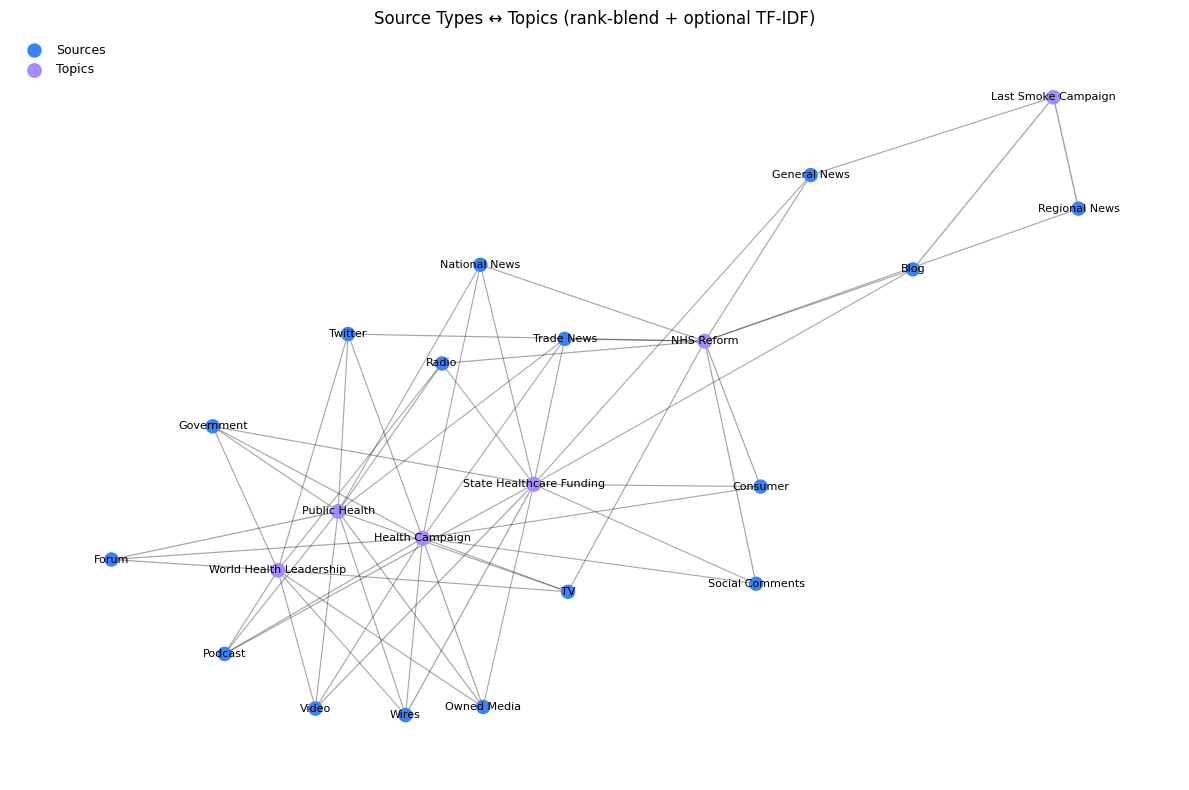

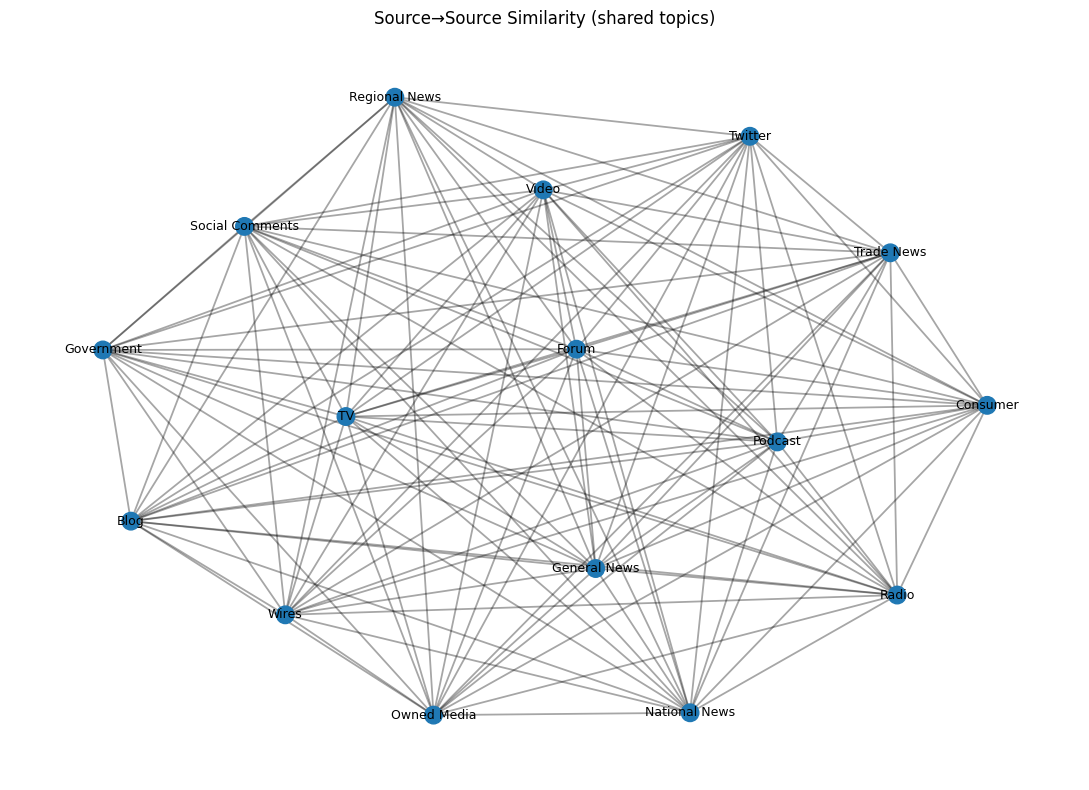

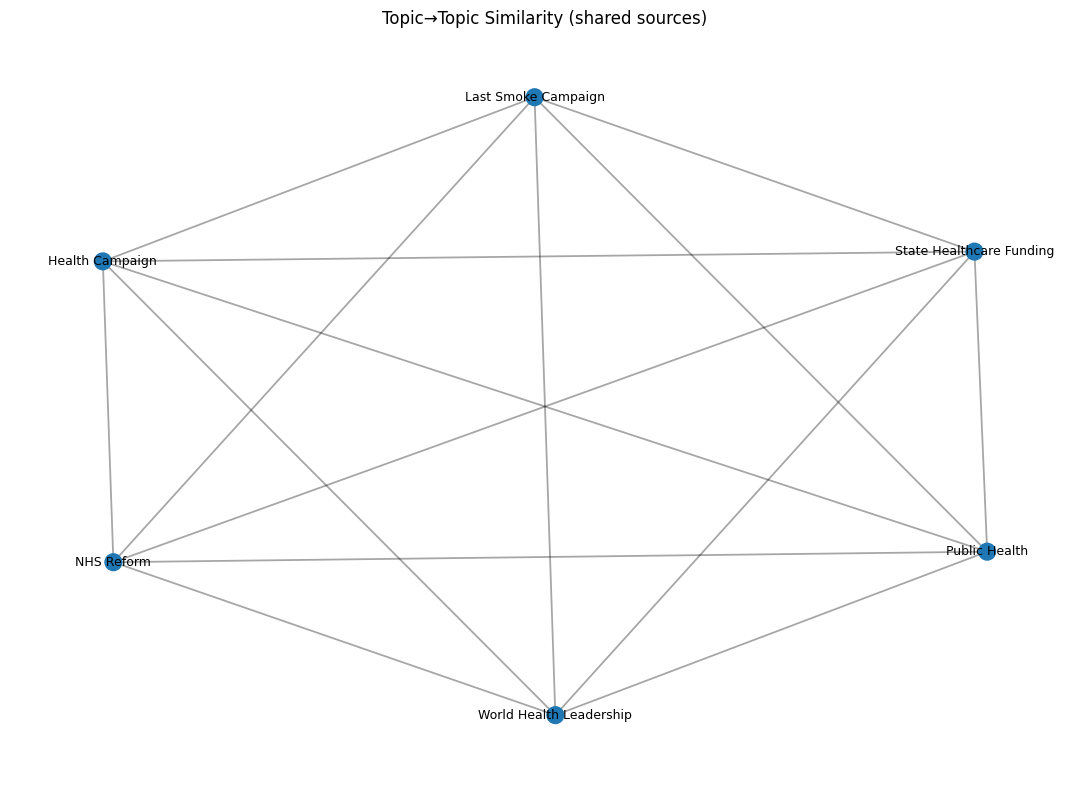

In [ ]:
#4) Build + visualize + lists
B, agg, sources, topics = build_source_topic_bipartite(
    DF,
    source_col=SOURCE_COL,
    topic_col=TOPIC_COL,
    weight_by=WEIGHT_BY,
    weight_weights=WEIGHT_WEIGHTS,
    min_edge_weight=MIN_EDGE_WEIGHT,
    min_topics_per_source=MIN_TOPICS_PER_SOURCE,
    min_sources_per_topic=MIN_SOURCES_PER_TOPIC,
    use_tfidf=USE_TFIDF,
    use_sum_instead_of_mean=False
)

print("edges kept in agg:", len(agg))
print("sources:", len(sources), "topics:", len(topics))
display(agg.sort_values("weight", ascending=False).head(15))

# Auto-relax if everything was pruned
if len(agg)==0 or len(sources)==0 or len(topics)==0:
    print("Nothing left after thresholds → relaxing filters...")
    B, agg, sources, topics = build_source_topic_bipartite(
        DF, SOURCE_COL, TOPIC_COL,
        weight_by=WEIGHT_BY, weight_weights=WEIGHT_WEIGHTS,
        min_edge_weight=0.0, min_topics_per_source=1, min_sources_per_topic=1,
        use_tfidf=False, use_sum_instead_of_mean=False
    )
    print("RELAXED → edges:", len(agg), "sources:", len(sources), "topics:", len(topics))

# Visuals
visualize_bipartite(B, sources, topics,
    title="Source Types ↔ Topics (rank-blend + optional TF-IDF)",
    label_sources_top=LABEL_SOURCES_TOP,
    label_topics_top=LABEL_TOPICS_TOP,
    edge_keep_pct=EDGE_KEEP_PCT_BIP
)

Gs = project_sources(B, sources, method="overlap")
visualize_projection(Gs, title="Source→Source Similarity (shared topics)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

Gt = project_topics(B, topics, method="overlap")
visualize_projection(Gt, title="Topic→Topic Similarity (shared sources)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)



In [ ]:
edge_table = agg.sort_values("weight", ascending=False).reset_index(drop=True)
display(edge_table.head(25))

,source_type_name,tag_name,weight
0,Regional News,Last Smoke Campaign,0.568121
1,Blog,Last Smoke Campaign,0.406157
2,Wires,State Healthcare Funding,0.372242
3,Forum,World Health Leadership,0.352036
4,Forum,Public Health,0.351374
5,Social Comments,NHS Reform,0.338797
6,Forum,Health Campaign,0.333664
7,Consumer,NHS Reform,0.318473
8,Video,State Healthcare Funding,0.316558
9,Owned Media,Health Campaign,0.315365


In [ ]:
### Top Topic per Source
def top_k_topics_per_source(agg: pd.DataFrame, source_col=SOURCE_COL, topic_col=TOPIC_COL, k=10) -> pd.DataFrame:
    if agg.empty: return agg
    return (agg.sort_values(["weight"], ascending=False)
              .groupby(source_col, group_keys=False)
              .head(k)
              .reset_index(drop=True))

display(top_k_topics_per_source(agg, k=8).head(30))


,source_type_name,tag_name,weight
0,Regional News,Last Smoke Campaign,0.568121
1,Blog,Last Smoke Campaign,0.406157
2,Wires,State Healthcare Funding,0.372242
3,Forum,World Health Leadership,0.352036
4,Forum,Public Health,0.351374
5,Social Comments,NHS Reform,0.338797
6,Forum,Health Campaign,0.333664
7,Consumer,NHS Reform,0.318473
8,Video,State Healthcare Funding,0.316558
9,Owned Media,Health Campaign,0.315365


In [ ]:
### Top Sources per Topic (ranking within each topic)
def top_k_sources_per_topic(agg: pd.DataFrame, source_col=SOURCE_COL, topic_col=TOPIC_COL, k=10) -> pd.DataFrame:
    if agg.empty: return agg
    return (agg.sort_values(["weight"], ascending=False)
              .groupby(topic_col, group_keys=False)
              .head(k)
              .reset_index(drop=True))

display(top_k_sources_per_topic(agg, k=8).head(30))

,source_type_name,tag_name,weight
0,Regional News,Last Smoke Campaign,0.568121
1,Blog,Last Smoke Campaign,0.406157
2,Wires,State Healthcare Funding,0.372242
3,Forum,World Health Leadership,0.352036
4,Forum,Public Health,0.351374
5,Social Comments,NHS Reform,0.338797
6,Forum,Health Campaign,0.333664
7,Consumer,NHS Reform,0.318473
8,Video,State Healthcare Funding,0.316558
9,Owned Media,Health Campaign,0.315365


In [ ]:
# Strength tables (weighted degree)
def _node_strength(G):
    return {n: sum(G[n][nbr].get("weight",1) for nbr in G.neighbors(n)) for n in G.nodes()}
if B.number_of_nodes() > 0:
    S = _node_strength(B)
    display(pd.Series({n:s for n,s in S.items() if n in sources}, name="strength")
              .sort_values(ascending=False).head(25).to_frame())
    display(pd.Series({n:s for n,s in S.items() if n in topics},  name="strength")
              .sort_values(ascending=False).head(25).to_frame())

,strength
Regional News,1.461508
Blog,1.366885
General News,1.301070
Social Comments,1.156399
Consumer,1.151910
National News,1.148702
Trade News,1.146348
Radio,1.143112
Twitter,1.138822
TV,1.128086


,strength
Health Campaign,3.748227
Public Health,3.630320
State Healthcare Funding,3.471337
World Health Leadership,3.458884
NHS Reform,2.900287
Last Smoke Campaign,1.260590


In [ ]:
### Source -> Source (From Visual Above)
pairs_src = (pd.DataFrame([(u, v, d.get("weight", 1)) for u, v, d in Gs.edges(data=True)],
                          columns=["source_u", "source_v", "weight"])
               .sort_values("weight", ascending=False))
display(pairs_src.head(25))

,source_u,source_v,weight
0,Twitter,Consumer,1.0
1,Twitter,Regional News,1.0
2,Twitter,Radio,1.0
3,Twitter,Blog,1.0
4,Twitter,Forum,1.0
5,Twitter,Podcast,1.0
6,Twitter,Owned Media,1.0
7,Twitter,Wires,1.0
8,Twitter,Trade News,1.0
9,Twitter,Government,1.0


In [ ]:
### Topic -> Topic (From Visual)
pairs_topic = (pd.DataFrame([(u, v, d.get("weight", 1)) for u, v, d in Gt.edges(data=True)],
                            columns=["topic_u", "topic_v", "weight"])
                 .sort_values("weight", ascending=False))
display(pairs_topic.head(25))

,topic_u,topic_v,weight
0,Last Smoke Campaign,Public Health,1.0
1,Last Smoke Campaign,World Health Leadership,1.0
2,Last Smoke Campaign,NHS Reform,1.0
3,Last Smoke Campaign,State Healthcare Funding,1.0
4,Last Smoke Campaign,Health Campaign,1.0
5,Public Health,World Health Leadership,1.0
6,Public Health,NHS Reform,1.0
7,Public Health,State Healthcare Funding,1.0
8,Public Health,Health Campaign,1.0
9,World Health Leadership,NHS Reform,1.0
